In [ ]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI
## 2026.03.04 woody_pro:: upload the HE-StarDist embedding and predict the cell type of NCRT_tumor1  
## 2026.03.06 woody_pro:: clearn code 
## 2026.03.13 update cell type level1: nanually make codex_meta_celltype_level1.csv 
## 2026.03.16 use valis to make registration [dont try]
## 2026.03.18 delete two subtypes, adjust scale factor by batch
## 2026.03.19 Train and using NCRT_train.ipynb
## 2026.03.23 Adjust file name and path

In [44]:
import sys
import os
import importlib
import pandas as pd
from pathlib import Path

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
import base
import plot
## Impost：Force reload base.py
importlib.reload(base)  
importlib.reload(plot)  

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    plot_per_class_f1,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment,
    load_cell_pixcoords,load_hist_embeddings,
    match_hist2cell_matrix
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_cell_area_histogram,
    plot_confusion_matrix
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


## reset pathway
os.chdir(f'{path}Hist2Pheno/data/CODEX/ESCC')
therapy_data = 'NCRT'
segment_data1 = f'{therapy_data}_project - seg 1-14'
segment_data2 = f'{therapy_data}_project - seg 15-28'
export_data = 'export'
save_result = 'result'

stardist_data = 'StarDist_Segment'
transfer_data = 'he_cell_coords'
qupath_corner = 'QupathCorners'

Successfully reloaded functions from base.py
openslide: False, tifffile: True


## Cell Type Classification Model

In [4]:
## Load celltype data (ground truth Y) - celltype_pixel_NCRT_tumor1
# cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1.csv'
# celltype_pixel_NCRT_tumor1 = load_cell_pixcoords(cell_coords_path)

## Load HIPT embeddings from .pth files (Input X)
# hist_embedding_dir = Path(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_data}_project_tumor1/ImgEmbeddings_tumor1/sc_pth_16_16')
# embeddings_dict = load_hist_embeddings(hist_embedding_dir)

# import pickle
# matched_data_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_data}_project_tumor1/matched_data_tumor1.pkl'

In [4]:
## Match embeddings with celltype data by coordinates
cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1.csv'
hist_embedding_dir = Path(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_data}_project_tumor1/ImgEmbeddings_tumor1/sc_pth_16_16')
matched_features_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_data}_project_tumor1/matched_features_tumor1.npz'

# Coordinate matching tolerance in pixels (float supported).
match_tolerance = 1.0
X, y, X_coords_matched = match_hist2cell_matrix(
    cell_coords_path,
    hist_embedding_dir,
    matched_features_path,
    coord_cols=('X_pix_HE', 'Y_pix_HE'),
    tolerance=match_tolerance,
)

Loading celltype Ground Truth ...
  Loaded 80303 cells
  Cell types: 40 unique types

Loading HIPT embeddings from .pth files...
  Loading embeddings...


Loading .pth files: 100%|██████████| 80303/80303 [00:25<00:00, 3179.48it/s]


  Successfully loaded 80303 embeddings
  Embedding dimension: (384,)

Loading pre-saved matched data...
  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1.npz
  X shape: (80303, 384)
  y shape: (80303,)
  Number of classes: 40
  ✓ Coordinates found in saved data
  ✓ Coordinates loaded: (80303, 2)


### Train and test datasets 

In [5]:
## Train/Test split (70% / 30%)
## Fix: stratified split fails when some classes appear only once.
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

## Filter out classes with <2 samples
unique_labels, counts = np.unique(y_encoded, return_counts=True)
keep_labels = unique_labels[counts >= 2]
mask = np.isin(y_encoded, keep_labels)

X_f = X[mask]
y_f = y[mask]
y_encoded_f = y_encoded[mask]

## If only 1 class remains, stratify must be disabled
strat = y_encoded_f if len(keep_labels) > 1 else None

X_train, X_test, y_train, y_test, y_train_encoded, y_test_encoded = train_test_split(
    X_f, y_f, y_encoded_f,
    test_size=0.3,
    random_state=42,
    stratify=strat,
)

print(f"\nTrain/Test split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")
print(f"  Feature dimension: {X_train.shape[1]}")

## Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("  Features standardized")


Train/Test split:
  Training set: 56211 samples
  Test set: 24091 samples
  Feature dimension: 384
  Features standardized


## MLP classifier

In [6]:
# CUDA/CPU sanity check for training setup
import os
import sys
import torch

print(sys.executable)
print(
    f"torch {torch.__version__} | built with CUDA: {torch.version.cuda} | "
    f"cuda.is_available: {torch.cuda.is_available()}"
)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True  # Faster cuDNN for fixed-size inputs
    amp_scaler = torch.amp.GradScaler("cuda")  # AMP only on CUDA
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    allow_cpu = os.environ.get("NCRT_ALLOW_CPU_TRAIN", "").strip().lower() in ("1", "true", "yes")
    if allow_cpu:
        device, amp_scaler = torch.device("cpu"), None
        print("WARNING: CUDA unavailable, training on CPU (set NCRT_ALLOW_CPU_TRAIN=1).")
    else:
        raise RuntimeError(
            "CUDA unavailable. Please use a CUDA-enabled PyTorch build, "
            "or set NCRT_ALLOW_CPU_TRAIN=1 to run on CPU."
        )

print(f"device: {device}" + (f" | {torch.cuda.get_device_name(0)}" if device.type == "cuda" else ""))

/ssd2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
device: cuda | NVIDIA RTX PRO 6000 Blackwell Server Edition


In [7]:
## Create PyTorch Dataset and DataLoader
train_dataset, val_dataset, train_loader, val_loader = create_dataloaders(
    X_train_scaled, y_train_encoded, X_test_scaled, y_test_encoded
)

Train dataset size: 56211
Val dataset size: 24091
Batch size: 1024
Feature dimension: 384


In [8]:
## Helper utilities shared by training/validation modes.
def infer_input_dim_and_num_classes(
    X_train_scaled,
    y_train_encoded,
    y_test_encoded,
    class_names=None,
):
    """Infer model input dimension and class count."""
    input_dim = X_train_scaled.shape[1]
    if class_names is not None:
        num_classes = len(class_names)
    else:
        # Use full label space to avoid out-of-bounds targets.
        num_classes = int(np.max(np.concatenate([y_train_encoded, y_test_encoded]))) + 1
    return input_dim, num_classes


def build_mlp_classifier(
    input_dim,
    num_classes,
    device,
    hidden_dims=(1024, 512, 256),
    dropout=0.2,
):
    """Create the MLP classifier on the given device."""
    return ImprovedMLPClassifier(
        input_dim=input_dim,
        num_classes=num_classes,
        hidden_dims=list(hidden_dims),
        dropout=dropout,
    ).to(device)


def get_best_checkpoint_path(path, therapy_data):
    """Return the checkpoint path saved during training."""
    return (
        f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/"
        f"{therapy_data}_project_tumor1/best_mlp_gpu.pt"
    )


import torch.nn as nn
def train_and_save_model(
    device,
    X_train_scaled,
    train_loader,
    val_loader,
    evaluate,
    save_bestmodel_path,
    patience=10,
    max_epochs=50,
    hidden_dims=(1024, 512, 256),
    dropout=0.2,
    lr=1e-3,
    weight_decay=5e-5,
):
    # Create the parent directory safely (dirname() can be empty).
    save_dir = os.path.dirname(save_bestmodel_path)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    # Use AMP only on CUDA.
    amp_scaler = torch.amp.GradScaler(device.type) if device.type == "cuda" else None

    # Infer input dimension and class count.
    input_dim, num_classes = infer_input_dim_and_num_classes(
        X_train_scaled,
        y_train_encoded,
        y_test_encoded,
        class_names=class_names if 'class_names' in globals() else None,
    )

    print("Model configuration:")
    print(f"  Input dimension: {input_dim}")
    print(f"  Number of classes: {num_classes}")
    # print(f"  Class names: {class_names if 'class_names' in globals() else None}")

    # Build model before creating optimizer/scheduler.
    model = build_mlp_classifier(
        input_dim=input_dim,
        num_classes=num_classes,
        device=device,
        hidden_dims=hidden_dims,
        dropout=dropout,
    )

    print(f"Model initialized on {device}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Optimizer + scheduler.
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
        betas=(0.9, 0.999),
        eps=1e-8,
    )

    from torch.optim.lr_scheduler import OneCycleLR
    scheduler = OneCycleLR(
        optimizer,
        max_lr=lr,
        epochs=max_epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        anneal_strategy="cos",
    )

    # Class weights for imbalanced data.
    unique_classes = np.unique(y_train_encoded)
    from sklearn.utils.class_weight import compute_class_weight

    cw = compute_class_weight("balanced", classes=unique_classes, y=y_train_encoded)

    full_weights = np.ones(num_classes, dtype=np.float64)
    full_weights[unique_classes.astype(int)] = cw

    class_weights_tensor = torch.as_tensor(full_weights, dtype=torch.float32, device=device)

    print(f"Class weights: length {num_classes} (non-default for {len(unique_classes)} train-present classes)")
    print(f"  Weight range (train-present): min={cw.min():.3f}, max={cw.max():.3f}")
    print(f"  Weight tensor shape: {class_weights_tensor.shape}")

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # Train the model and save the best checkpoint.
    best_weighted_f1, best_macro_f1, best_epoch = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        scheduler,
        criterion,
        evaluate,
        device,
        amp_scaler,
        patience=patience,
        max_epochs=max_epochs,
        save_path=save_bestmodel_path,
    )

    return best_weighted_f1, best_macro_f1, best_epoch


In [9]:
## Path to save the best model
save_bestmodel_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_data}_project_tumor1/best_mlp_gpu.pt"

best_weighted_f1, best_macro_f1, best_epoch = train_and_save_model(
    device, X_train_scaled, train_loader, val_loader,
    evaluate, save_bestmodel_path,
    patience=10, max_epochs=50
)

Model configuration:
  Input dimension: 384
  Number of classes: 40
Model initialized on cuda
Model parameters: 1,064,232
Class weights: length 40 (non-default for 39 train-present classes)
  Weight range (train-present): min=0.125, max=360.327
  Weight tensor shape: torch.Size([40])
Starting training with improved model...

Epoch 1/50 (1.56s, LR: 0.000132)
  Train Loss: 5.5548
  Val Accuracy: 0.1333
  Val Macro-F1: 0.0483
  Val Weighted-F1: 0.1463
  ✓ Best model saved (Weighted-F1: 0.1463, Macro-F1: 0.0483)

Epoch 2/50 (1.27s, LR: 0.000374)
  Train Loss: 4.3933
  Val Accuracy: 0.2247
  Val Macro-F1: 0.0795
  Val Weighted-F1: 0.2430
  ✓ Best model saved (Weighted-F1: 0.2430, Macro-F1: 0.0795)

Epoch 3/50 (0.76s, LR: 0.000671)
  Train Loss: 3.7097
  Val Accuracy: 0.2403
  Val Macro-F1: 0.0878
  Val Weighted-F1: 0.2633
  ✓ Best model saved (Weighted-F1: 0.2633, Macro-F1: 0.0878)

Epoch 4/50 (1.09s, LR: 0.000911)
  Train Loss: 3.2715
  Val Accuracy: 0.2286
  Val Macro-F1: 0.0841
  Val Wei

In [10]:
def mode_validation(
    val_loader,
    device,
    path,
    therapy_data,
    X_train_scaled,
    y_train_encoded,
    y_test_encoded,
    class_names=None,
    hidden_dims=(1024, 512, 256),
    dropout=0.2,
):
    # Infer input dimension and class count.
    input_dim, num_classes = infer_input_dim_and_num_classes(
        X_train_scaled,
        y_train_encoded,
        y_test_encoded,
        class_names=class_names,
    )

    # Build the same model architecture used during training.
    model = build_mlp_classifier(
        input_dim=input_dim,
        num_classes=num_classes,
        device=device,
        hidden_dims=hidden_dims,
        dropout=dropout,
    )

    checkpoint_path = get_best_checkpoint_path(path, therapy_data)
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)

    # Run prediction evaluation on val_loader.
    val_acc, val_macro_f1, val_weighted_f1, val_preds, val_labels = evaluate(
        model, val_loader, device
    )

    print("\nValidation Performance (best checkpoint on val_loader):")
    print(f"  Accuracy: {val_acc:.4f}")
    print(f"  Macro F1-score: {val_macro_f1:.4f}")
    print(f"  Weighted F1-score: {val_weighted_f1:.4f}")

    # Only report classes that actually appear in the validation set.
    unique_labels = np.unique(np.concatenate([val_labels, val_preds]))
    actual_class_names = (
        [class_names[i] for i in unique_labels]
        if class_names is not None
        else [str(i) for i in unique_labels]
    )

    from sklearn.metrics import classification_report

    print("\nDetailed Classification Report (val_loader):")
    print(f"  Number of classes in validation: {len(unique_labels)}")
    print(
        classification_report(
            val_labels,
            val_preds,
            labels=unique_labels,
            target_names=actual_class_names,
            zero_division=0,
        )
    )

    # Return model + input_dim for downstream plotting.
    return model, input_dim, val_acc, val_macro_f1, val_weighted_f1, val_preds, val_labels

In [12]:
## validate model on validation dataset
model, input_dim, val_acc, val_macro_f1, val_weighted_f1, val_preds, val_labels = mode_validation(
    val_loader=val_loader,
    device=device,
    path=path,
    therapy_data=therapy_data,
    X_train_scaled=X_train_scaled,
    y_train_encoded=y_train_encoded,
    y_test_encoded=y_test_encoded,
    class_names=class_names if 'class_names' in globals() else None,
)


Validation Performance (best checkpoint on val_loader):
  Accuracy: 0.3676
  Macro F1-score: 0.1393
  Weighted F1-score: 0.3707

Detailed Classification Report (val_loader):
  Number of classes in validation: 39
                       precision    recall  f1-score   support

              B_other       0.05      0.15      0.07       128
      B_proliferating       0.00      0.00      0.00        18
          Bm_switched       0.02      0.08      0.04       113
        Bm_unswitched       0.04      0.16      0.06       106
                   Bn       0.00      0.00      0.00        21
               CAF_ap       0.02      0.13      0.03        67
            CAF_other       0.25      0.11      0.15      1254
              CD4_Tcm       0.00      0.00      0.00         1
              CD4_Tem       0.02      0.11      0.04        82
              CD4_Tex       0.12      0.07      0.08       751
               CD4_Tn       0.00      0.00      0.00        16
             CD8_Teff       0.

Computing confusion matrix...
Figure saved to NCRT/result/conf_matrix_tumor1.pdf


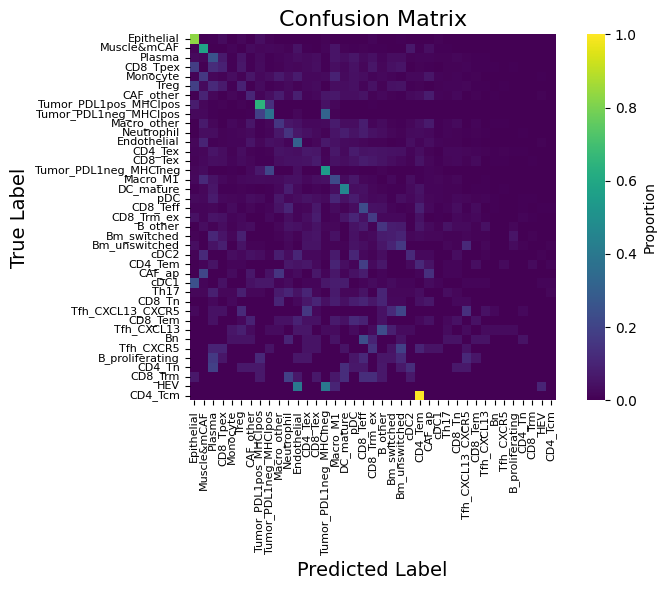

In [23]:
plot_confusion_matrix(val_labels, val_preds, class_names, 
                      # hierarchical=True,
                      # save_path=None)
                      save_path=f'{therapy_data}/{save_result}/conf_matrix_tumor1.pdf')

Visualizing per-class performance...
  ✓ Computed metrics for 39 classes


Figure saved to NCRT/result/f1_per_class_tumor1.pdf


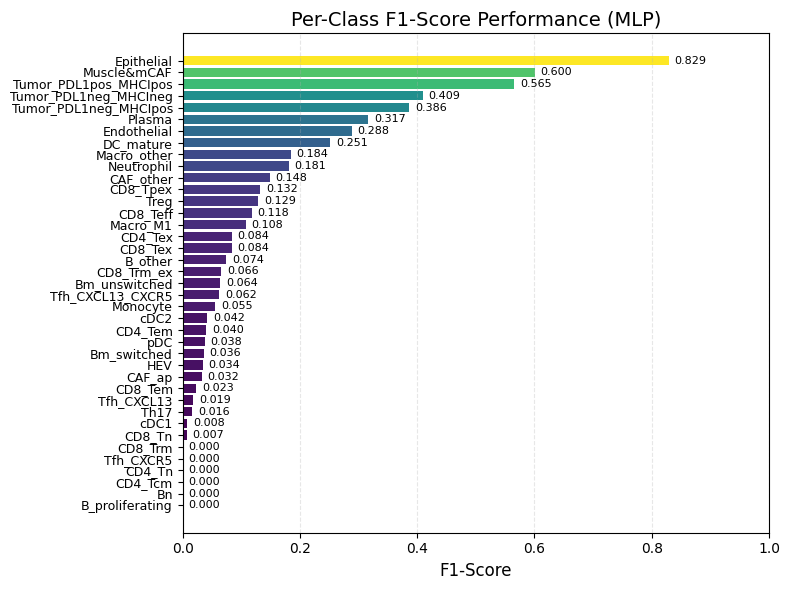


Model Summary:
  Device: cuda
  Training samples: 56211
  Test samples: 24091
  Total classes (before filtering): 40
  Actual classes in test set: 39
  Feature dimension: 384
  Model parameters: 1,064,232
  Best epoch: 45
  Test Accuracy: 0.3676
  Test Macro F1: 0.1393
  Test Weighted F1: 0.3707


In [24]:
metrics_df = plot_per_class_f1(
    val_labels,
    val_preds,
    class_names,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_acc,
    test_macro_f1=val_macro_f1,
    test_weighted_f1=val_weighted_f1,
    model_name="MLP",
    # save_path="per_class_f1.pdf")
    save_path=f'{therapy_data}/{save_result}/f1_per_class_tumor1.pdf')


  Loading data from matched_features_path...
  ✓ Loaded X from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1.npz: (80303, 384)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1.npz: (80303,), dtype: <U21
  ⚠ Note: Labels will be used for evaluation. If encoding mismatch occurs, set prediction_only=True.
  ⚠ y contains string labels. Encoding to integers...
  ⚠ Warning: New LabelEncoder may produce different encoding than training!
  ⚠ This can cause label mismatch if data has different classes than training.
  ✓ Encoded y to integers: (80303,), dtype: int64
  ⚠ Encoded labels have 40 unique classes (0-39)
  ⚠ Model expects unknown classes
  ✓ Scaled X using provided scaler
  X_all_scaled shape: (80303, 384)
  y_all_encoded shape: (80303,)
  ✓ Final y_all_encoded dtype: int64
X_all_scaled:  (80303, 384)
y_all_encoded:  (80303,)
  ⚠ Large dataset detected (80303 samples).

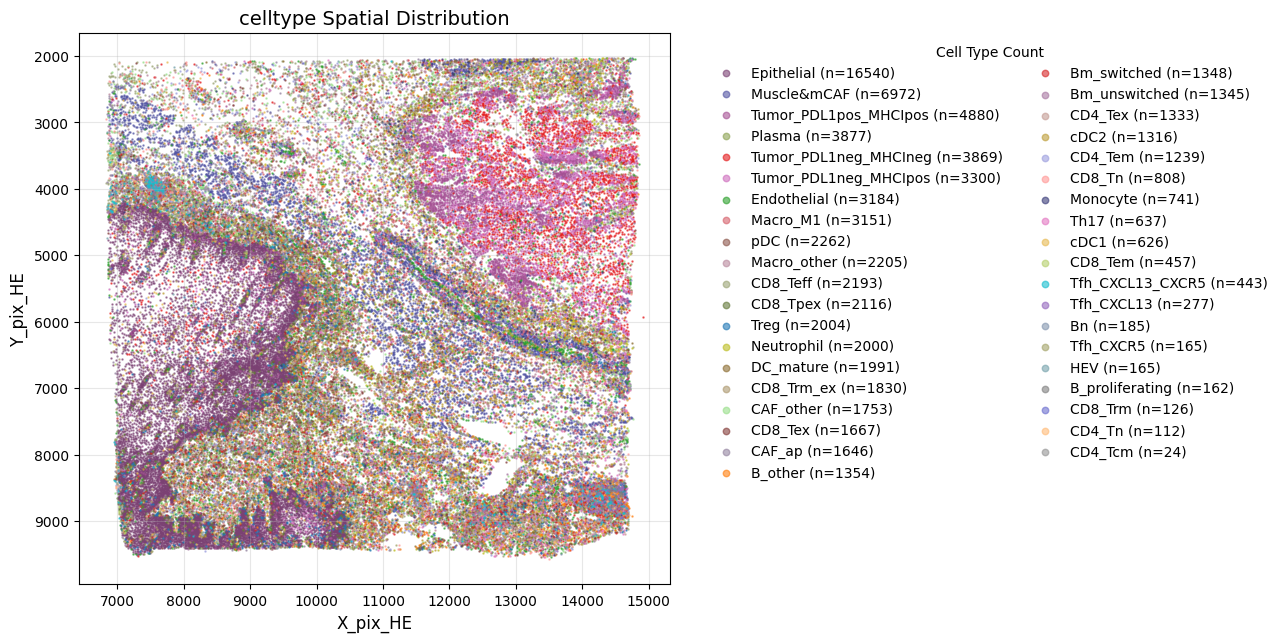

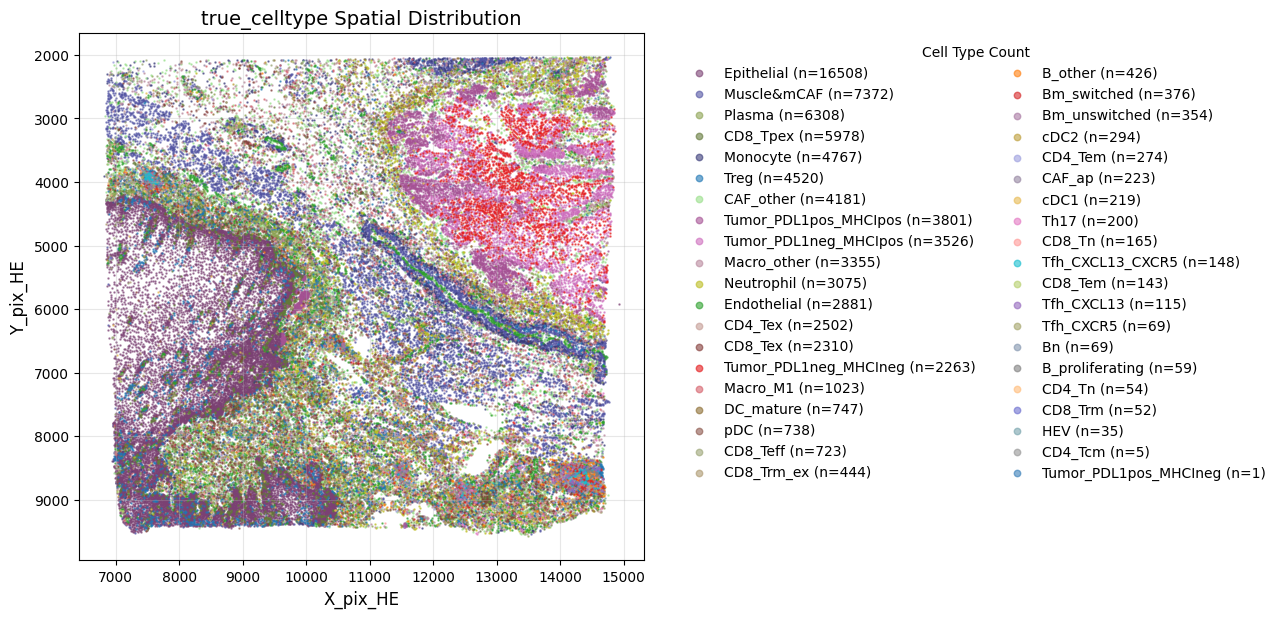

In [ ]:
## Evaluate on all data and plot spatial distribution
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model,
    matched_features_path=matched_features_path,
    class_names=class_names,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=val_loader if 'val_loader' in globals() else None,
    X=X if 'X' in globals() else None,
    y=y if 'y' in globals() else None,
    y_encoded=y_encoded if 'y_encoded' in globals() else None,
    X_train=X_train if 'X_train' in globals() else None,
    X_train_scaled=X_train_scaled if 'X_train_scaled' in globals() else None,
    X_test_scaled=X_test_scaled if 'X_test_scaled' in globals() else None,
    y_train_encoded=y_train_encoded if 'y_train_encoded' in globals() else None,
    y_test_encoded=y_test_encoded if 'y_test_encoded' in globals() else None,
    min_samples_per_class=min_samples_per_class if 'min_samples_per_class' in globals() else 29,
    X_coords_matched=X_coords_matched if 'X_coords_matched' in globals() else None,
    celltype_pred_dir = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/celltype_valid_tumor1_level2.jpg',
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if 'celltype_pixel_NCRT_tumor1' in globals() else None
)

## HE-feature validation

In [29]:
## Load stardist coords from YuLu - no duplicates
star_coords = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{stardist_data}/{therapy_data}_Float_prob0.01_nms_0.3.csv')
# print(star_coords.shape)
# star_coords.head() 

## filter ROI using ROI coords from Qupath annotation by myself
roi_coords = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{qupath_corner}/{therapy_data}_ROI_Corners.csv')
# print(roi_coords.shape)
# roi_coords.head()

## Load GT and CellPixCoords
celltype_anno_df = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv')
celltype_pixel_NCRT = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords.csv')


## Match StarCoords to ROI
# star_coords_out, star_coords_in_roi, roi_cell_counts = match_StarCoords2ROI(
star_coords_in_roi, roi_cell_counts = match_StarCoords2ROI(
    star_coords, roi_coords, therapy_data="NCRT"
)

/home/lingyu/ssd2/Python/Collaborate/esccAI/code/base.py:2849: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NCRT_tumor27' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  s=0.6


Number of rows with TumorID = NaN: 2676
star_coords shape after filtering: (2025438, 4)
       TumorID   centroid_x   centroid_y  probability
0  NCRT_tumor1  6863.988266  3320.483284     0.884281
1  NCRT_tumor1  7168.098045  1736.226154     0.878382
2  NCRT_tumor1  7189.928642  1536.107811     0.877665
3  NCRT_tumor1  7227.680878  1686.196735     0.875756
4  NCRT_tumor1  7272.088211  2399.935646     0.872943
Nuclei number within each ROI (sorted by TumorID):
         TumorID  cell_count
2    NCRT_tumor1       94963
4    NCRT_tumor2       91422
26   NCRT_tumor3       43568
18   NCRT_tumor4       65337
5    NCRT_tumor5       86115
23   NCRT_tumor6       58079
27   NCRT_tumor7       25843
25   NCRT_tumor8       53104
10   NCRT_tumor9       77542
24  NCRT_tumor10       57359
8   NCRT_tumor11       79697
9   NCRT_tumor12       79563
14  NCRT_tumor13       72766
11  NCRT_tumor14       74430
21  NCRT_tumor15       60176
20  NCRT_tumor16       61779
7   NCRT_tumor17       84053
3   NCRT_tumor1

ROIs where orange bar (HE: cell_count) is lower than blue bar (PCF: celltype_count):
['NCRT_tumor3', 'NCRT_tumor25']


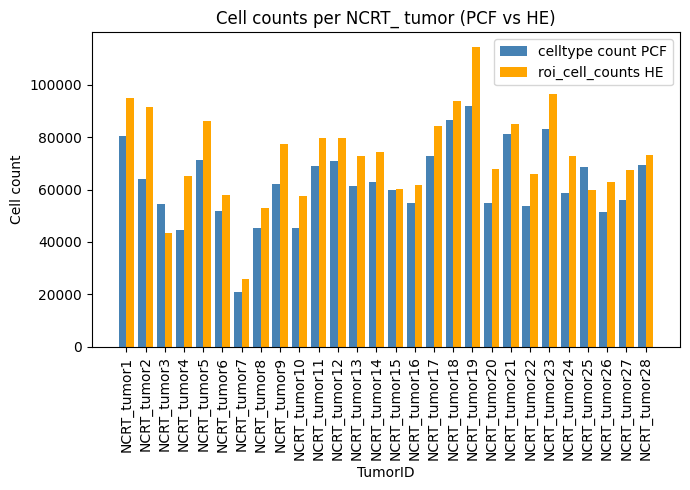

In [ ]:
merged = plot_WSI_counts(celltype_anno_df, roi_cell_counts, prefix='NCRT_', figure_size=(7,5),
                        #  save_path=None)
                        save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare.pdf')

NCRT_tumor3 - star_coords_in_roi shape: (43568, 4)
NCRT_tumor3 - celltype_pixel_NCRT shape: (54500, 13)


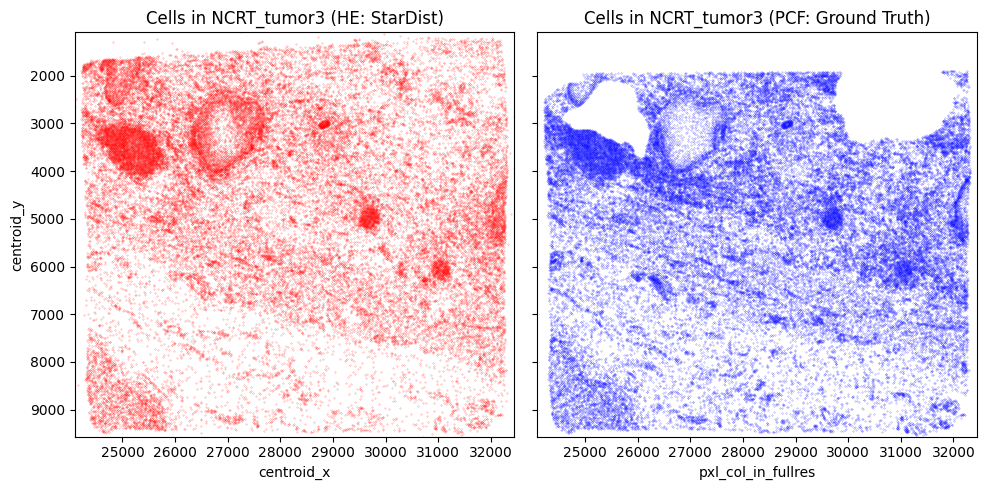

In [45]:
plot_PCF_HE_counts(star_coords_in_roi, celltype_pixel_NCRT, ROI='NCRT_tumor3', figure_size=(10,5),
                   #  save_path=None)
                   save_path=f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/cellcounts_compare_tumor3.jpg')

In [47]:
## Load celltype_pixel_NCRT and StarDist in Tumor1
celltype_pixel_NCRT_tumor1 = celltype_pixel_NCRT[celltype_pixel_NCRT['TumorID']=='NCRT_tumor1']
print("cell number in GroundTruth of tumor1", celltype_pixel_NCRT_tumor1.shape[0])
# celltype_pixel_NCRT_tumor1.head()

## Match celltype_pixel_NCRT_tumor1 to StarDist in Tumor1
star_coords_in_roi1 = star_coords_in_roi[star_coords_in_roi['TumorID']=='NCRT_tumor1']
print("cell number in StarDist of tumor1", star_coords_in_roi1.shape[0])
# star_coords_in_roi1.head()

## Match celltype_pixel_NCRT_tumor1 to StarDist in Tumor1
celltype_pixel_NCRT_stardist = match_celltype2stardist(
    celltype_pixel_NCRT_tumor1, 
    star_coords_in_roi1, 
    celltype_pixel_coords_cols=['X_pix_HE', 'Y_pix_HE'], 
    stardist_pixel_coords_cols=['centroid_x', 'centroid_y']
)
celltype_pixel_NCRT_stardist.head()

cell number in GroundTruth of tumor1 80303
cell number in StarDist of tumor1 94963
celltype_pixel_coords shape: (80303, 2)
stardist_pixel_coords shape: (94963, 2)
Building KDTree for star_coords...
Finding 100 nearest neighbors for each celltype point...
Nearest neighbor search completed. Distance matrix shape: (80303, 100)

Using greedy nearest neighbor matching...
Matched 77996 points
Matched distance: Mean, Median, Max: 10.28, 4.87, 270.92

Matched points summary:
  Total points in celltype_pixel_coords: 80303
  Matched points: 77996
  Unmatched points: 2307
Matched of PCF-HE-StarDist: (77996, 16)


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE,X_um_HE,Y_um_HE,centroid_x,centroid_y,matched_distance
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,4159.0,1.242,8183.007536,2.443687,13885.887175,2031.339753,6943.028787,1015.682340,13900.303383,2030.153347,14.464944
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid,3970.5,2.817,7812.125853,5.542566,13508.928169,2037.450502,6754.546971,1018.737752,13506.714867,2039.506466,3.020876
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid,4027.5,2.793,7924.275751,5.495345,13622.922877,2036.507170,6811.545024,1018.266080,13618.529022,2037.792927,4.578114
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,4172.1,3.086,8208.782337,6.071835,13912.115011,2034.821824,6956.142865,1017.423397,13904.389221,2037.292774,8.111314
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid,3996.6,3.635,7863.478701,7.152015,13561.138767,2038.676462,6780.652590,1019.350740,13558.002533,2016.124191,22.769297


In [ ]:
# ## Save to new file
# celltype_pixel_NCRT_stardist.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1_StarDist.csv', index=False)

In [ ]:
# ## Save to new file for HIPT
# celltype_pixel_NCRT_stardist.rename(columns={'centroid_x': 'pxl_row_in_fullres', 'centroid_y': 'pxl_col_in_fullres'}, inplace=True)
# celltype_pixel_NCRT_stardist.to_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1_StarDist_ViT.csv')

In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required) - 6m57.2s
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NCRT \
#    --position_path data/he_cell_coords/NCRT_CellPixCoords_tumor1_StarDist_ViT.csv \
#    --rawimage_path 'data/NCRT/NCRT HE.qptiff' \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1_stardist/sc_pth_16_16_image \
#    --output_pth data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1_stardist/sc_pth_16_16 \
#    --logging data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1_stardist/ \
#    --scale 0.5  

## Predict StarDist

In [50]:
# Load HIPT embeddings for StarDist predictions.
print("Loading HIPT embeddings for StarDist...")

embedding_star_dir = Path(
    f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_data}_project_tumor1/"
    "ImgEmbeddings_tumor1_stardist/sc_pth_16_16"
)
embeddings_star_dict = load_hist_embeddings(embedding_star_dir)

Loading HIPT embeddings for StarDist...
Loading HIPT embeddings from .pth files...
  Loading embeddings...


Loading .pth files:   0%|          | 0/77996 [00:00<?, ?it/s]

Loading .pth files: 100%|██████████| 77996/77996 [00:13<00:00, 5598.79it/s]

  Successfully loaded 77996 embeddings
  Embedding dimension: (384,)



In [51]:
celltype_pixel_NCRT_stardist = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/{transfer_data}/{therapy_data}_CellPixCoords_tumor1_StarDist.csv')
celltype_pixel_NCRT_stardist.head()

,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE,X_um_HE,Y_um_HE,centroid_x,centroid_y,matched_distance
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,4159.0,1.242,8183.007536,2.443687,13885.887175,2031.339753,6943.028787,1015.682340,13900.303383,2030.153347,14.464944
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid,3970.5,2.817,7812.125853,5.542566,13508.928169,2037.450502,6754.546971,1018.737752,13506.714867,2039.506466,3.020876
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid,4027.5,2.793,7924.275751,5.495345,13622.922877,2036.507170,6811.545024,1018.266080,13618.529022,2037.792927,4.578114
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,4172.1,3.086,8208.782337,6.071835,13912.115011,2034.821824,6956.142865,1017.423397,13904.389221,2037.292774,8.111314
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid,3996.6,3.635,7863.478701,7.152015,13561.138767,2038.676462,6780.652590,1019.350740,13558.002533,2016.124191,22.769297


In [52]:
# Match StarDist coordinates to embeddings and cache matched features.
matched_features_star_path = (
    f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_data}_project_tumor1/"
    "matched_features_tumor1_stardist.npz"
)

result_star = prepare_matched_embeddings(
    celltype_pixel_NCRT_stardist,
    embeddings_star_dict,
    matched_features_star_path,
    coord_cols=("centroid_x", "centroid_y"),
)

if len(result_star) == 3:
    X_star, y_star, X_coords_star = result_star
    if X_coords_star is not None:
        print(f"  ✓ StarDist coordinates loaded: {X_coords_star.shape}")
else:
    X_star, y_star = result_star
    X_coords_star = None
    print("  ⚠ StarDist coordinates not available (old format)")

Loading pre-saved matched data...
  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1_stardist.npz
  X shape: (77996, 384)
  y shape: (77996,)
  Number of classes: 40
  ✓ Coordinates found in saved data
  ✓ StarDist coordinates loaded: (77996, 2)


In [53]:
device

device(type='cuda')

In [54]:
# Load best model for StarDist prediction.
print("Loading best model for StarDist prediction...")

checkpoint_path = get_best_checkpoint_path(path, therapy_data)
state_dict = torch.load(checkpoint_path, map_location=device if "device" in globals() else "cpu")

# Infer model dimensions from checkpoint weights.
input_dim_star = state_dict["input_layer.0.weight"].shape[1]
num_classes_star = state_dict["output_layer.weight"].shape[0]

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_star = ImprovedMLPClassifier(
    input_dim=input_dim_star,
    num_classes=num_classes_star,
    hidden_dims=[1024, 512, 256],
    dropout=0.2,
).to(device)

model_star.load_state_dict(state_dict)
print("✓ StarDist model loaded")

Loading best model for StarDist prediction...
✓ StarDist model loaded


  Loading data from matched_features_path...
  ✓ Loaded X from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1_stardist.npz: (77996, 384)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1_stardist.npz: (77996,), dtype: <U21
  ⚠ prediction_only=True: Labels will be used for visualization only, not for evaluation.
  ✓ Keeping labels as strings for visualization (no encoding needed)
  ✓ Scaled X using provided scaler
  X_all_scaled shape: (77996, 384)
  No labels available - prediction mode only
X_all_scaled:  (77996, 384)
dummy_labels:  (77996,)
  ⚠ Large dataset detected (77996 samples). Setting num_workers=0 to avoid indexing issues.
  Total samples: 77996
  DataLoader batch_size: 1024, num_workers: 0
  Predicting on new data (no labels for evaluation)...


Predicting: 100%|██████████| 77/77 [00:00<00:00, 289.85it/s]



Prediction completed:
  Total predictions: 77996
  Predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 36 37 38 39]
  ✓ Using original labels for visualization: 77996 labels

Preparing spatial distribution plot...
  Matching predictions with coordinates...
  ✓ Loaded coordinates from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1_stardist.npz: (77996, 2)
  Coordinates shape: (77996, 2)
  Predictions shape: (77996,)
  ✓ Created prediction DataFrame with 77996 cells

Plotting spatial distribution of PREDICTED cell types...
Number of valid data points: 77996
Number of cell types: 39

Plotting spatial distribution of TRUE cell types (for comparison)...
Number of valid data points: 77996
Number of cell types: 39


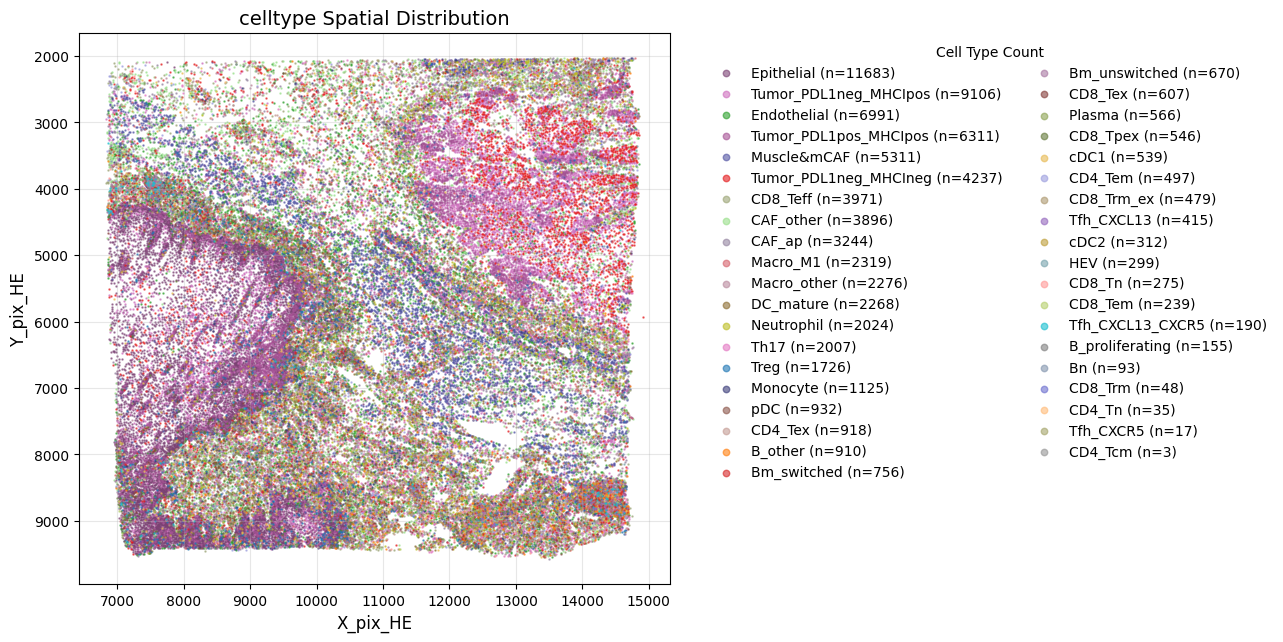

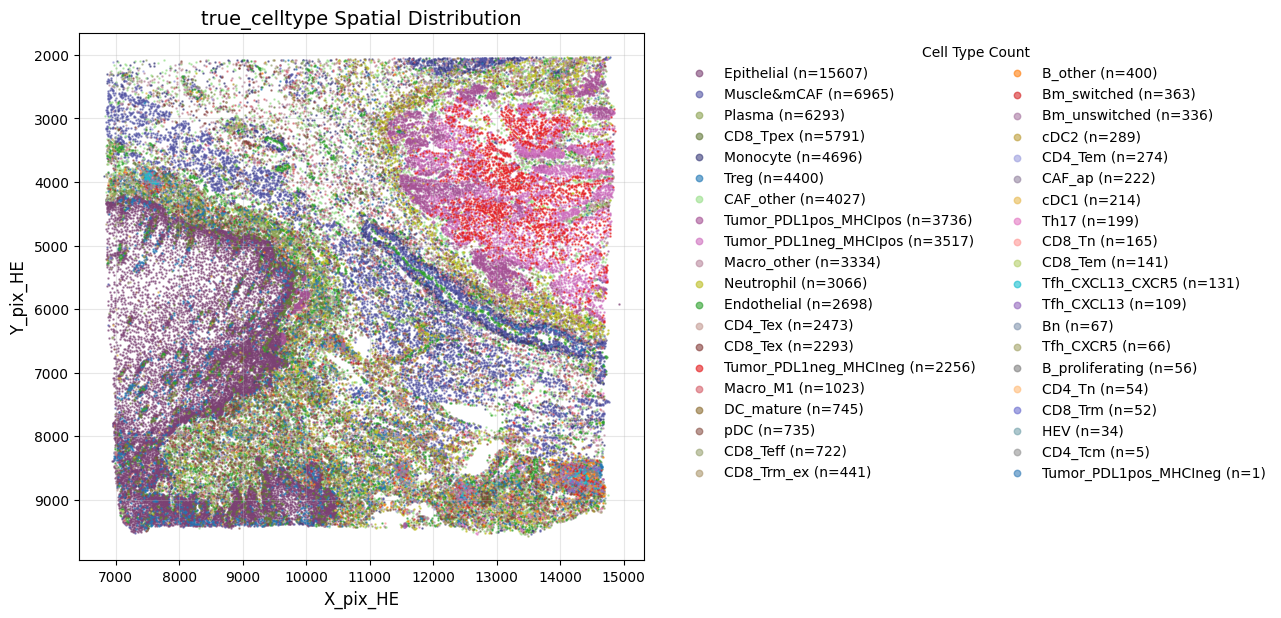

In [55]:
# Predict on StarDist-matched data and plot spatial distribution.
class_names_star = class_names if "class_names" in globals() and class_names is not None else [
    str(i) for i in range(num_classes_star)
]

all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model_star,
    matched_features_path=matched_features_star_path,
    class_names=class_names_star,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=None,
    prediction_only=True,
    # Optional coordinate fallback when X_coords are missing in npz.
    X_coords_matched=X_coords_star if "X_coords_star" in globals() else None,
    celltype_pred_dir = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/celltype_pred_tumor1_level2.jpg',
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_stardist if "celltype_pixel_NCRT_stardist" in globals() else None,
)
